# Amna Kauser

# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

In [1]:
# ============================================
# Term Deposit Subscription Prediction
# Bank Marketing Dataset Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

# Explainability
import shap

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


 # Load and explore the dataset

TERM DEPOSIT SUBSCRIPTION PREDICTION

1. DATASET OVERVIEW
----------------------------------------
Dataset shape: (11162, 17)

First 5 rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673     

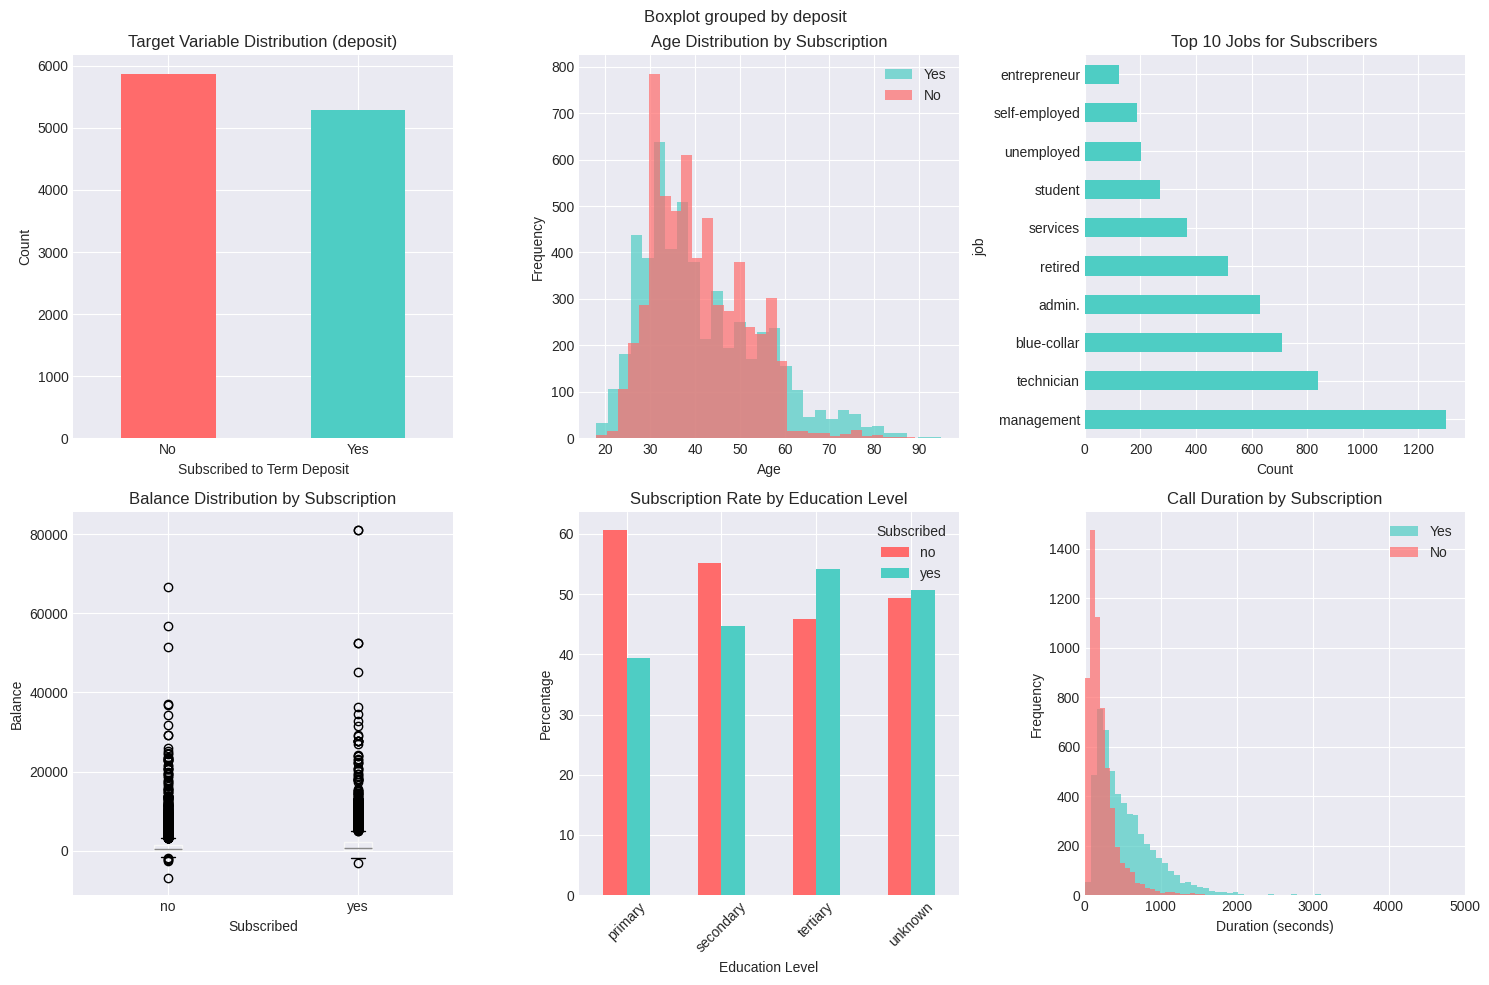

In [3]:
# ============================================
# 1. LOAD AND EXPLORE THE DATASET
# ============================================

# Load the dataset
df = pd.read_csv('/content/bank.csv')

print("=" * 60)
print("TERM DEPOSIT SUBSCRIPTION PREDICTION")
print("=" * 60)

print("\n1. DATASET OVERVIEW")
print("-" * 40)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nDataset info:")
df.info()

print(f"\nStatistical summary of numerical features:")
print(df.describe())

print(f"\nTarget variable distribution:")
print(df['deposit'].value_counts())
print(f"\nTarget variable percentages:")
print(df['deposit'].value_counts(normalize=True) * 100)

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# ============================================
# 2. DATA EXPLORATION VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Target distribution
df['deposit'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Target Variable Distribution (deposit)', fontsize=12)
axes[0, 0].set_xlabel('Subscribed to Term Deposit')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['No', 'Yes'], rotation=0)

# Age distribution by target
df[df['deposit'] == 'yes']['age'].hist(alpha=0.7, bins=30, label='Yes', ax=axes[0, 1], color='#4ECDC4')
df[df['deposit'] == 'no']['age'].hist(alpha=0.7, bins=30, label='No', ax=axes[0, 1], color='#FF6B6B')
axes[0, 1].set_title('Age Distribution by Subscription', fontsize=12)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Job distribution top 10
job_counts = df[df['deposit'] == 'yes']['job'].value_counts().head(10)
job_counts.plot(kind='barh', ax=axes[0, 2], color='#4ECDC4')
axes[0, 2].set_title('Top 10 Jobs for Subscribers', fontsize=12)
axes[0, 2].set_xlabel('Count')

# Balance distribution
df.boxplot(column='balance', by='deposit', ax=axes[1, 0])
axes[1, 0].set_title('Balance Distribution by Subscription', fontsize=12)
axes[1, 0].set_xlabel('Subscribed')
axes[1, 0].set_ylabel('Balance')

# Education by target
edu_pivot = pd.crosstab(df['education'], df['deposit'], normalize='index') * 100
edu_pivot.plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4'])
axes[1, 1].set_title('Subscription Rate by Education Level', fontsize=12)
axes[1, 1].set_xlabel('Education Level')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Subscribed')
axes[1, 1].tick_params(axis='x', rotation=45)

# Duration distribution
df[df['deposit'] == 'yes']['duration'].hist(alpha=0.7, bins=50, label='Yes', ax=axes[1, 2], color='#4ECDC4')
df[df['deposit'] == 'no']['duration'].hist(alpha=0.7, bins=50, label='No', ax=axes[1, 2], color='#FF6B6B')
axes[1, 2].set_title('Call Duration by Subscription', fontsize=12)
axes[1, 2].set_xlabel('Duration (seconds)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_xlim(0, 5000)
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('exploratory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()





# Encoding all categorical features

In [4]:
# ============================================
# 3. FEATURE ENGINEERING
# ============================================

print("\n" + "=" * 60)
print("2. FEATURE ENGINEERING")
print("=" * 60)

# Create a copy for processing
df_processed = df.copy()

# Convert target variable to binary
df_processed['deposit'] = df_processed['deposit'].map({'yes': 1, 'no': 0})

# Identify categorical and numerical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
if 'deposit' in categorical_cols:
    categorical_cols.remove('deposit')

numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'deposit' in numerical_cols:
    numerical_cols.remove('deposit')

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Create new features
# 1. Age groups
df_processed['age_group'] = pd.cut(df_processed['age'],
                                    bins=[0, 25, 35, 45, 55, 65, 100],
                                    labels=['Young', 'Young Adult', 'Adult', 'Middle Age', 'Senior', 'Elderly'])

# 2. Balance categories
df_processed['balance_group'] = pd.cut(df_processed['balance'],
                                        bins=[-float('inf'), 0, 1000, 5000, 10000, float('inf')],
                                        labels=['Negative', 'Low', 'Medium', 'High', 'Very High'])

# 3. Campaign intensity
df_processed['campaign_intensity'] = df_processed['campaign'].apply(lambda x: 'Low' if x <= 2 else ('Medium' if x <= 4 else 'High'))

# 4. Previous contact success indicator
df_processed['previous_success'] = (df_processed['poutcome'] == 'success').astype(int)

# 5. Contact rate (campaign / age)
df_processed['contact_rate'] = df_processed['campaign'] / (df_processed['age'] + 1)

# Update categorical columns with new features
categorical_cols.extend(['age_group', 'balance_group', 'campaign_intensity'])

print(f"\nNew features created:")
print("- age_group (age categories)")
print("- balance_group (balance categories)")
print("- campaign_intensity (contact intensity)")
print("- previous_success (whether previous campaign was successful)")
print("- contact_rate (campaign calls per age)")

# ============================================
# 4. ENCODE CATEGORICAL FEATURES
# ============================================

print("\n" + "=" * 60)
print("3. ENCODING CATEGORICAL FEATURES")
print("=" * 60)

# Separate features and target
X = df_processed.drop('deposit', axis=1)
y = df_processed['deposit']

# Identify final categorical columns
final_categorical_cols = [col for col in categorical_cols if col in X.columns]
final_numerical_cols = [col for col in numerical_cols if col in X.columns]

print(f"\nFinal categorical columns ({len(final_categorical_cols)}): {final_categorical_cols}")
print(f"Final numerical columns ({len(final_numerical_cols)}): {final_numerical_cols}")

# Apply Label Encoding to categorical features
label_encoders = {}
for col in final_categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}' with {len(le.classes_)} unique values")

# Scale numerical features
scaler = StandardScaler()
X[final_numerical_cols] = scaler.fit_transform(X[final_numerical_cols])

print(f"\nDataset shape after encoding: {X.shape}")




2. FEATURE ENGINEERING

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

New features created:
- age_group (age categories)
- balance_group (balance categories)
- campaign_intensity (contact intensity)
- previous_success (whether previous campaign was successful)
- contact_rate (campaign calls per age)

3. ENCODING CATEGORICAL FEATURES

Final categorical columns (12): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group', 'balance_group', 'campaign_intensity']
Final numerical columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Encoded 'job' with 12 unique values
Encoded 'marital' with 3 unique values
Encoded 'education' with 4 unique values
Encoded 'default' with 2 unique values
Encoded 'housing' with 2 unique values
Encoded 'loan' with 2 unique va

# Train classification models

In [5]:
# ============================================
# 5. TRAIN-TEST SPLIT
# ============================================

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{y_train.value_counts(normalize=True)}")

# ============================================
# 6. TRAIN CLASSIFICATION MODELS
# ============================================

print("\n" + "=" * 60)
print("4. MODEL TRAINING AND EVALUATION")
print("=" * 60)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_split=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, random_state=42)
}

# Cross-validation results
print("\nCross-Validation Results (5-fold):")
print("-" * 50)

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = cv_scores
    print(f"{name}:")
    print(f"  CV F1-Scores: {cv_scores}")
    print(f"  Mean F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train models and evaluate on test set
print("\nTest Set Evaluation:")
print("-" * 50)

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 40)

    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'f1_score': f1,
        'auc': auc
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:")
    print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

    print(f"\nF1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")



Training set size: 8929 samples
Test set size: 2233 samples
Training set class distribution:
deposit
0    0.526151
1    0.473849
Name: proportion, dtype: float64

4. MODEL TRAINING AND EVALUATION

Cross-Validation Results (5-fold):
--------------------------------------------------
Logistic Regression:
  CV F1-Scores: [0.77928483 0.77846535 0.79705702 0.78820698 0.77300613]
  Mean F1-Score: 0.7832 (+/- 0.0169)
Decision Tree:
  CV F1-Scores: [0.80069124 0.78613396 0.80597015 0.77644231 0.80392157]
  Mean F1-Score: 0.7946 (+/- 0.0229)
Random Forest:
  CV F1-Scores: [0.83162685 0.83371824 0.84113229 0.83010262 0.82678984]
  Mean F1-Score: 0.8327 (+/- 0.0096)

Test Set Evaluation:
--------------------------------------------------

Logistic Regression:
----------------------------------------
Confusion Matrix:
  TN: 996, FP: 179
  FN: 255, TP: 803

Classification Report:
              precision    recall  f1-score   support

          No       0.80      0.85      0.82      1175
         Y

 # Evaluate the models using Confusion Matrix, F1-Score, and ROC Curve

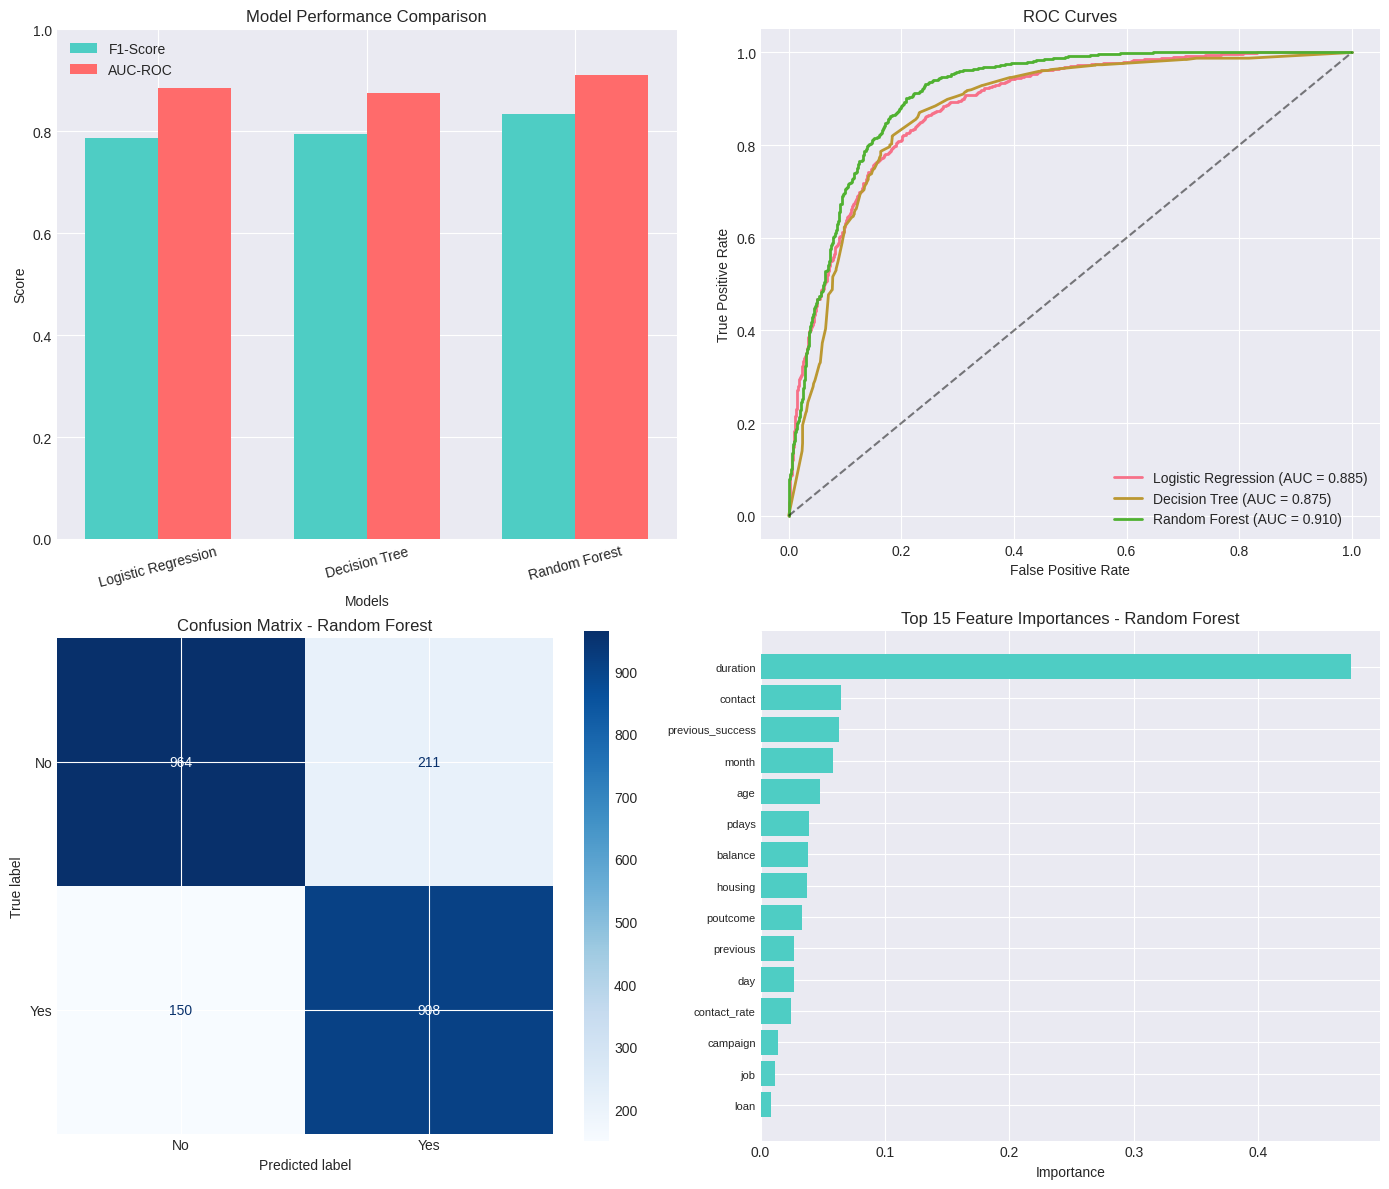

In [6]:
# ============================================
# 7. VISUALIZE MODEL COMPARISON
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. F1-Score comparison
models_names = list(results.keys())
f1_scores = [results[m]['f1_score'] for m in models_names]
auc_scores = [results[m]['auc'] for m in models_names]

x = np.arange(len(models_names))
width = 0.35

axes[0, 0].bar(x - width/2, f1_scores, width, label='F1-Score', color='#4ECDC4')
axes[0, 0].bar(x + width/2, auc_scores, width, label='AUC-ROC', color='#FF6B6B')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_names, rotation=15)
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1)

# 2. ROC Curves
for name in models_names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
    axes[0, 1].plot(fpr, tpr, label=f"{name} (AUC = {results[name]['auc']:.3f})", linewidth=2)

axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curves')
axes[0, 1].legend(loc='lower right')

# 3. Confusion Matrix for Best Model (Random Forest)
best_model_name = models_names[np.argmax(f1_scores)]
best_model = trained_models[best_model_name]
best_pred = results[best_model_name]['predictions']

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[1, 0], cmap='Blues', values_format='d')
axes[1, 0].set_title(f'Confusion Matrix - {best_model_name}')

# 4. Feature Importance (Random Forest)
if best_model_name == 'Random Forest':
    feature_importance = best_model.feature_importances_
    feature_names = X.columns
    importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
    importance_df = importance_df.sort_values('importance', ascending=True).tail(15)

    axes[1, 1].barh(importance_df['feature'], importance_df['importance'], color='#4ECDC4')
    axes[1, 1].set_xlabel('Importance')
    axes[1, 1].set_title(f'Top 15 Feature Importances - {best_model_name}')
    axes[1, 1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


# SHAP or LIME to explain at least 5 model predictions



5. SHAP EXPLANATIONS - 5 PREDICTIONS

Using Random Forest for SHAP explanations

Selecting 5 random test samples for explanation...

PREDICTION 1 - Sample Explanation
True Label: Not Subscribed
Predicted: Not Subscribed (Probability: 0.127)
Prediction Correct: ✓

Feature Values:
  age: -0.6071
  job: 1
  marital: 0
  education: 1
  default: 0
  balance: -0.1251
  housing: 1
  loan: 1
  contact: 0
  day: 0.3969

Top 5 Features Influencing This Prediction:
  • duration: -0.1876 - ↓ DECREASES probability
  • housing: -0.0409 - ↓ DECREASES probability
  • loan: -0.0284 - ↓ DECREASES probability
  • previous_success: -0.0223 - ↓ DECREASES probability
  • previous: -0.0175 - ↓ DECREASES probability

Actual Values for Top Features:
  duration: 141.00 (scaled: -0.67)
  housing: 1
  loan: 1
  previous_success: 0
  previous: 0.00 (scaled: -0.36)

PREDICTION 2 - Sample Explanation
True Label: Subscribed
Predicted: Subscribed (Probability: 0.694)
Prediction Correct: ✓

Feature Values:
  age: 0.06

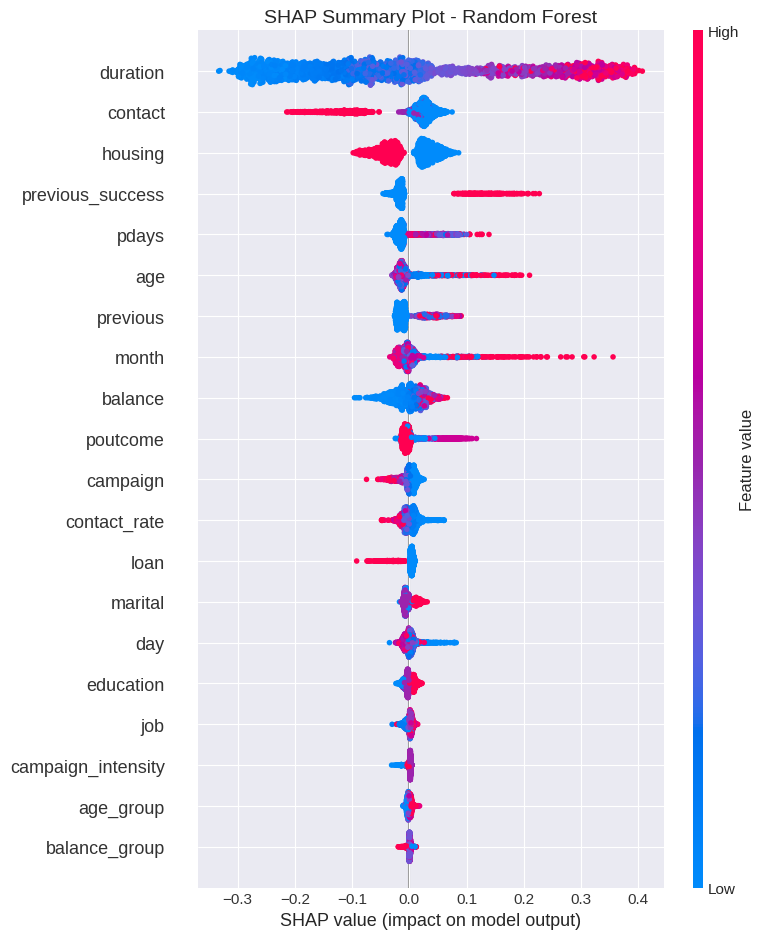

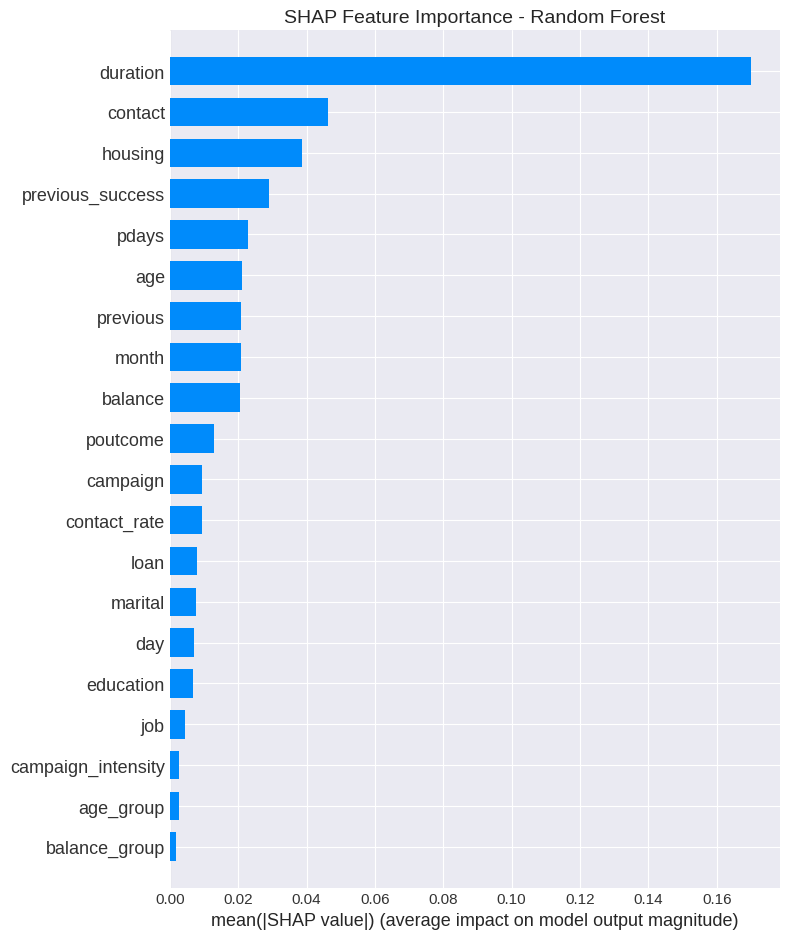

In [11]:
# ============================================
# 8. SHAP EXPLANATIONS
# ============================================

print("\n" + "=" * 60)
print("5. SHAP EXPLANATIONS - 5 PREDICTIONS")
print("=" * 60)

# Use the best performing model for SHAP analysis
best_model_name = models_names[np.argmax(f1_scores)]
best_model = trained_models[best_model_name]

# Initialize SHAP explainer
if best_model_name == 'Random Forest':
    explainer = shap.TreeExplainer(best_model)
    shap_values_raw = explainer.shap_values(X_test)
    if isinstance(shap_values_raw, list) and len(shap_values_raw) > 1: # Common for TreeExplainer: list of (n_samples, n_features) arrays
        shap_values = shap_values_raw[1]  # Get values for class 1
    elif isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3: # If it's a 3D array (n_samples, n_features, n_classes)
        shap_values = shap_values_raw[:, :, 1] # Select class 1
    else:
        shap_values = shap_values_raw # Assume it's already (n_samples, n_features) or single output

elif best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, X_train)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3: # If it's a 3D array (n_samples, n_features, n_classes)
        shap_values = shap_values[:, :, 1] # Select class 1

else:  # Decision Tree
    explainer = shap.TreeExplainer(best_model)
    shap_values_raw = explainer.shap_values(X_test)
    if isinstance(shap_values_raw, list) and len(shap_values_raw) > 1:
        shap_values = shap_values_raw[1]
    elif isinstance(shap_values_raw, np.ndarray) and len(shap_values_raw.shape) == 3:
        shap_values = shap_values_raw[:, :, 1]
    else:
        shap_values = shap_values_raw

# Ensure shap_values has (n_samples, n_features) shape
# This addresses cases where SHAP might return (n_features, n_samples)
if shap_values.shape[0] == X_test.shape[1] and shap_values.shape[1] == X_test.shape[0]:
    shap_values = shap_values.T # Transpose if it's (n_features, n_samples)

print(f"\nUsing {best_model_name} for SHAP explanations")
print(f"\nSelecting 5 random test samples for explanation...")

# Select 5 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 5, replace=False)

feature_names = X.columns.tolist()

# Create explanations for each sample
for idx, sample_idx in enumerate(sample_indices, 1):
    print(f"\n{'='*50}")
    print(f"PREDICTION {idx} - Sample Explanation")
    print(f"{'='*50}")

    sample = X_test.iloc[sample_idx:sample_idx+1]
    true_label = y_test.iloc[sample_idx]
    pred_label = best_model.predict(sample)[0]
    pred_proba = best_model.predict_proba(sample)[0][1]

    print(f"True Label: {'Subscribed' if true_label == 1 else 'Not Subscribed'}")
    print(f"Predicted: {'Subscribed' if pred_label == 1 else 'Not Subscribed'} (Probability: {pred_proba:.3f})")
    print(f"Prediction Correct: {'✓' if true_label == pred_label else '✗'}")

    print(f"\nFeature Values:")
    for col in feature_names[:10]:  # Show top 10 features
        value = sample[col].values[0]
        print(f"  {col}: {value:.4f}" if isinstance(value, float) else f"  {col}: {value}")

    # Get SHAP values for this sample
    # shap_values is now guaranteed to be (n_samples, n_features)
    shap_sample = shap_values[sample_idx]

    # Get top contributing features
    feature_contributions = list(zip(feature_names, shap_sample))
    feature_contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print(f"\nTop 5 Features Influencing This Prediction:")
    for feat_name, contribution in feature_contributions[:5]:
        direction = "↑ INCREASES probability" if contribution > 0 else "↓ DECREASES probability"
        print(f"  • {feat_name}: {contribution:+.4f} - {direction}")

    # Get actual feature values for top contributing features
    print(f"\nActual Values for Top Features:")
    for feat_name, _ in feature_contributions[:5]:
        value = sample[feat_name].values[0]
        if isinstance(value, float):
            # For scaled numerical features, interpret
            if feat_name in final_numerical_cols:
                # Inverse transform for interpretation
                orig_val = value * scaler.scale_[final_numerical_cols.index(feat_name)] + scaler.mean_[final_numerical_cols.index(feat_name)]
                print(f"  {feat_name}: {orig_val:.2f} (scaled: {value:.2f})")
            else:
                print(f"  {feat_name}: {value:.4f}")
        else:
            print(f"  {feat_name}: {value}")

# Global SHAP summary plot
print("\nGenerating global SHAP summary plot...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary Plot - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP bar plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()